# AdD 2B2026 - Actividad 2

## EDA básico

Se seleccionó el dataset "Air Crashes Full Data 1908 - 2024".

Se realizó un EDA básico del dataset seleccionado:
- Clasificación de variables.
- Estadística descriptiva.
- Relación entre variables.
- Gráficos.


### Presentación del dataset

Se descarga el dataset desde Kaggle y se instancia como un DataFrame de Pandas.

In [70]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para que los archivos se descarguen en la carpeta "datasets" dentro del proyecto
os.environ["KAGGLEHUB_CACHE"] = "../"

# Descarga el dataset y obtiene la ruta a los archivos descargados
path = kagglehub.dataset_download("jogwums/air-crashes-full-data-1908-2023")

print("Path to dataset files:", path)

Path to dataset files: ../datasets/jogwums/air-crashes-full-data-1908-2023/versions/2


In [71]:
# Cargar el dataset en un DataFrame de Pandas
dataset_path = os.path.join(path, "aircrahesFullDataUpdated_2024.csv")
df = pd.read_csv(dataset_path)
# Mostrar información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5035 entries, 0 to 5034
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Year                   5035 non-null   int64
 1   Quarter                5035 non-null   str  
 2   Month                  5035 non-null   str  
 3   Day                    5035 non-null   int64
 4   Country/Region         4805 non-null   str  
 5   Aircraft Manufacturer  5035 non-null   str  
 6   Aircraft               5035 non-null   str  
 7   Location               5035 non-null   str  
 8   Operator               4801 non-null   str  
 9   Ground                 5035 non-null   int64
 10  Fatalities (air)       5035 non-null   int64
 11  Aboard                 5035 non-null   int64
dtypes: int64(5), str(7)
memory usage: 472.2 KB


In [72]:
# Mostrar las primeras filas del DataFrame
df.head()

,Year,Quarter,Month,Day,Country/Region,Aircraft Manufacturer,Aircraft,Location,Operator,Ground,Fatalities (air),Aboard
0,1970,Qtr 2,April,28,NaN,de Havilland Canada,de Havilland Canada DHC 6 Twin Otter 100VH,Kainatu,Airlines Australia GuineaTrans New,0,8,11
1,1952,Qtr 2,April,30,NaN,Douglas,Douglas DC 3VT,Delhi,Airways IndiaDeccan,0,9,9
2,1973,Qtr 2,April,10,NaN,Vickers Vanguard,Vickers Vanguard 952G AXOP,Near Basel,(UK) Airlines International SwitzerlandInvicta,0,108,145
3,2000,Qtr 2,April,19,'-,Antonov,Antonov AN 8TL,Pepa -,Airlines Centrafricain,0,24,24
4,1946,Qtr 2,April,30,'-,Douglas,Douglas C 47A FZ559,Pindi-Khut -,Force Air Royal,0,12,12


In [73]:
# Mostrar las últimas filas del DataFrame
df.tail()

,Year,Quarter,Month,Day,Country/Region,Aircraft Manufacturer,Aircraft,Location,Operator,Ground,Fatalities (air),Aboard
5030,1980,Qtr 3,September,17,Zaire,De Havilland,de Havilland DHC 5 Buffalo9T,Near Kindu Zaire,Force Air Zairean - Military,0,36,36
5031,1997,Qtr 3,September,12,Zaire,de Havilland Canada,de Havilland Canada DHC 6 Twin Otter 3009Q,Near Uvira Zaire,Commuter Air TMK,0,22,22
5032,1984,Qtr 3,September,11,Zaire,Handley Page Dart Herald,Handley Page Dart Herald 2029Q CAH,Near the Kwango River Zaire,Services Aero MMM,0,30,30
5033,1980,Qtr 3,September,14,Zaire,Lockheed Hercules,Lockheed Hercules C 1309T,Kindu Zaire,Zaïroise Aérienne Force - Military,0,36,36
5034,1961,Qtr 3,September,17,Zambia,Douglas,Douglas DC 6BSE,Ndola Zambia,Sweden Transair,0,16,16


In [74]:
# Se verifican valores nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nValores duplicados:")
print(df.duplicated().sum())

Valores nulos por columna:
Year                       0
Quarter                    0
Month                      0
Day                        0
Country/Region           230
Aircraft Manufacturer      0
Aircraft                   0
Location                   0
Operator                 234
Ground                     0
Fatalities (air)           0
Aboard                     0
dtype: int64

Valores duplicados:
0


No existen valores duplicados.

Los valores nulos de *Country/Region* y *Operator* no afectan en gran medida al análisis porque no son muchos en comparación con la muestra total.

### Clasificación de variables

Se procede a clasificar las variables del dataset en numéricas y categóricas. Para ello se utilizan los métodos `select_dtypes` de Pandas para obtener las columnas de cada tipo.

In [75]:
# Listar variables numéricas
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()
print("Variables numéricas:", numerical_vars)

# Listar variables categóricas
categorical_vars = df.select_dtypes(include=['str', 'object', 'category']).columns.tolist()
print("Variables categóricas:", categorical_vars)

Variables numéricas: ['Year', 'Day', 'Ground', 'Fatalities (air)', 'Aboard']
Variables categóricas: ['Quarter', 'Month', 'Country/Region', 'Aircraft Manufacturer', 'Aircraft', 'Location', 'Operator']


Podemos observar que el dataset contiene variables numéricas únicamente discretas. Se podría tomar *Year* como una variable numérica continua, pero dado que representa años específicos, se clasifica como discreta.

Respecto a las variables categórticas, son todas de tipo nominal, ya que representan categorías sin un orden o jerarquía inherente.

### Estadística descriptiva

Se procede a realizar un análisis de estadística descriptiva del dataset, obteniendo medidas de tendencia central, dispersión y forma para las variables numéricas, y concentración, frecuencias y variabilidad para las variables categóricas.

Se aplicará tanto estadística clásica como robusta, para obtener una visión completa de la distribución de los datos.

#### Variables numéricas

Por cada variable numérica:
- Year
- Day
- Ground
- Fatalities
- Aboard

Estadística clásica:
- Tendencia central: media, mediana y moda.
- Dispersión: rango, varianza y desviación estándar.
- Forma: asimetría y curtosis.

Estadística robusta:
- Tendencia central: mediana y media recortada.
- Dispersión: rango intercuartílico (IQR) y desviación absoluta mediana (MAD).

In [76]:
# Generar las medidas de tendencia central, dispersión y forma para las variables numéricas
df[numerical_vars].describe()

,Year,Day,Ground,Fatalities (air),Aboard
count,5035.000000,5035.000000,5035.000000,5035.000000,5035.000000
mean,1970.991063,15.785104,1.704469,22.218868,31.107249
std,24.814467,8.794474,55.105115,34.948929,45.740185
min,1908.000000,1.000000,0.000000,0.000000,0.000000
25%,1951.000000,8.000000,0.000000,4.000000,7.000000
50%,1970.000000,16.000000,0.000000,11.000000,16.000000
75%,1992.000000,23.000000,0.000000,25.000000,34.500000
max,2024.000000,31.000000,2750.000000,583.000000,644.000000


A simple vista parece bastante extraño que la variable *Ground*, que parece tener la mayoría de sus valores igual a 0, tenga un valor máximo de 2750. Verificando en Kaggle y en la base de datos original (https://www.planecrashinfo.com/), este es un outlier extremo correspondiente al atentado yihadista del 11 de septiembre de 2001 a las Torres Gemelas, donde murieron 2750 personas en tierra.

Resulta intersante que no existen faltantes entre las variables numéricas, todas las observaciones tienen datos válidos.

##### Year: Estadística clásica

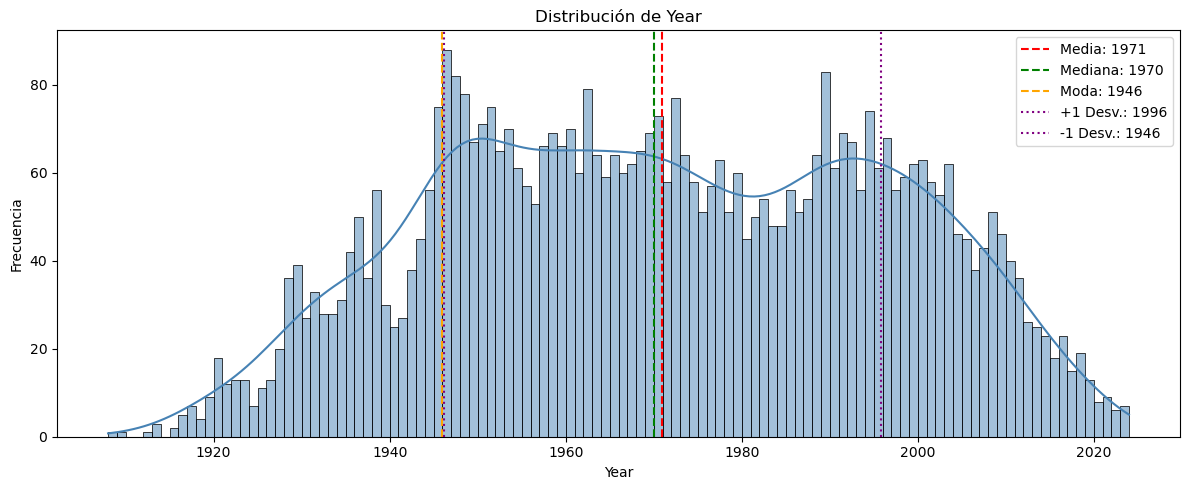

In [77]:
# Se grafica el hisograma con las medidas de tendencia central y dispersión para la variable "Year"
mean   = df['Year'].mean()
median = df['Year'].median()
mode   = df['Year'].mode()[0]
std    = df['Year'].std()

plt.figure(figsize=(12, 5))
sns.histplot(df['Year'], kde=True, color='steelblue', bins=range(1908, 2025))

plt.axvline(mean,       color='red',    linestyle='--', linewidth=1.5, label=f'Media: {mean:.0f}')
plt.axvline(median,     color='green',  linestyle='--', linewidth=1.5, label=f'Mediana: {median:.0f}')
plt.axvline(mode,       color='orange', linestyle='--', linewidth=1.5, label=f'Moda: {mode}')
plt.axvline(mean + std, color='purple', linestyle=':',  linewidth=1.5, label=f'+1 Desv.: {mean+std:.0f}')
plt.axvline(mean - std, color='purple', linestyle=':',  linewidth=1.5, label=f'-1 Desv.: {mean-std:.0f}')

plt.title('Distribución de Year')
plt.xlabel('Year')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()


In [78]:
# Se calculan las medidas de dispersión para la variable "Year"
variance = df['Year'].var()
std_dev  = df['Year'].std()
print(f'Varianza de Year: {variance:.2f}')
print(f'Desvío estándar de Year: {std_dev:.2f}')

Varianza de Year: 615.76
Desvío estándar de Year: 24.81


In [79]:
# Se calcula la curtosis y la asimetría para la variable "Year"
kurtosis = df['Year'].kurtosis()
skewness = df['Year'].skew()
print(f'Curtosis de Year: {kurtosis:.2f}')
print(f'Asimetría de Year: {skewness:.2f}')

Curtosis de Year: -0.94
Asimetría de Year: -0.02


Respecto a las medidas de forma de "Year", se observa que es aproximadamente simétrica (asimetría cercana a 0) y es un poco platicúrtica (curtosis cerca a -1). Esto coincide exactamente con en análisis visual del histograma, que muestra una distribución bastante uniforme a lo largo de los años, sin picos pronunciados ni colas pesadas.

##### Year: Estadística robusta

In [80]:
# Se calculan los cuartiles para la variable "Year"
q1 = df['Year'].quantile(0.25)
q2 = df['Year'].quantile(0.50)
q3 = df['Year'].quantile(0.75)
print(f'Primer cuartil (Q1) de Year: {q1:.0f}')
print(f'Segundo cuartil (Q2) de Year: {q2:.0f}. Es igual a la mediana.')
print(f'Tercer cuartil (Q3) de Year: {q3:.0f}')

# Se calcula la desviación absoluta mediana (MAD) para la variable "Year"
mad = (df['Year'] - df['Year'].median()).abs().median()
print(f'Desviación absoluta mediana (MAD) de Year: {mad:.2f}')

# Se calcula el rango intercuartílico (IQR) para la variable "Year"
iqr = q3 - q1
rango_total = df['Year'].max() - df['Year'].min()
print(f'Rango intercuartílico (IQR) de Year: {iqr:.0f} ({iqr/rango_total*100:.2f}%)')

Primer cuartil (Q1) de Year: 1951
Segundo cuartil (Q2) de Year: 1970. Es igual a la mediana.
Tercer cuartil (Q3) de Year: 1992
Desviación absoluta mediana (MAD) de Year: 20.00
Rango intercuartílico (IQR) de Year: 41 (35.34%)


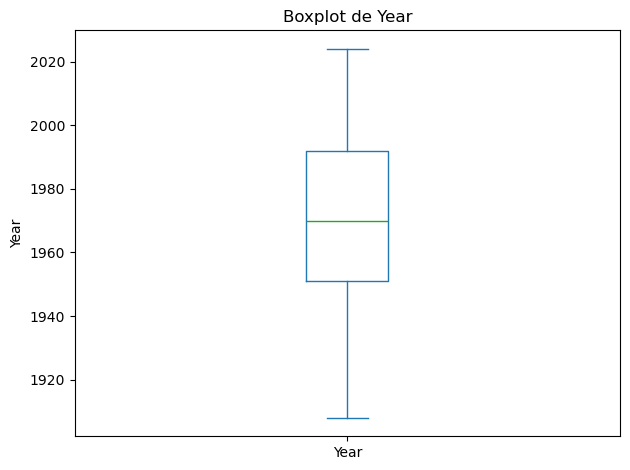

In [102]:
# Se grafica el boxplot para la variable "Year"
df['Year'].plot.box()
plt.title('Boxplot de Year')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

En este caso la estadística robusta nos aporta mayor claridad sobre la desviación de los datos. Existe una dispersión importante (IQR > 20%), concentrándose la mayoría de los accidentes entre 1950 y 2000, con un pico en los años 70. Esto se refleja también en el MAD, que es bastante alto (casi 20 años), indicando que hay una gran variabilidad en los años de los accidentes.

##### Day: Estadística clásica

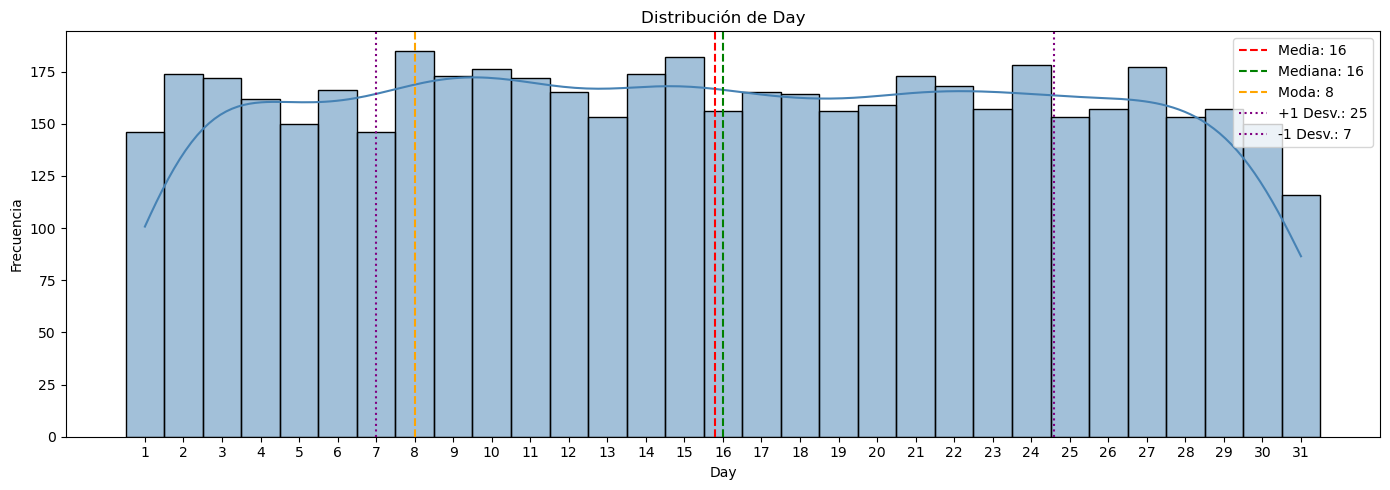

In [81]:
mean   = df['Day'].mean()
median = df['Day'].median()
mode   = df['Day'].mode()[0]
std    = df['Day'].std()

plt.figure(figsize=(14, 5))
sns.histplot(df['Day'], kde=True, discrete=True, color='steelblue')

plt.axvline(mean,       color='red',    linestyle='--', linewidth=1.5, label=f'Media: {mean:.0f}')
plt.axvline(median,     color='green',  linestyle='--', linewidth=1.5, label=f'Mediana: {median:.0f}')
plt.axvline(mode,       color='orange', linestyle='--', linewidth=1.5, label=f'Moda: {mode}')
plt.axvline(mean + std, color='purple', linestyle=':',  linewidth=1.5, label=f'+1 Desv.: {mean+std:.0f}')
plt.axvline(mean - std, color='purple', linestyle=':',  linewidth=1.5, label=f'-1 Desv.: {mean-std:.0f}')

plt.title('Distribución de Day')
plt.xlabel('Day')
plt.ylabel('Frecuencia')
plt.xticks(range(1, 32))
plt.legend()
plt.tight_layout()
plt.show()


In [82]:
# Se calculan las medidas de dispersión para la variable "Day"
variance = df['Day'].var()
std_dev  = df['Day'].std()
print(f'Varianza de Day: {variance:.2f}')
print(f'Desvío estándar de Day: {std_dev:.2f}')

Varianza de Day: 77.34
Desvío estándar de Day: 8.79


In [83]:
# Se calcula la curtosis y la asimetría para la variable "Day"
kurtosis = df['Day'].kurtosis()
skewness = df['Day'].skew()
print(f'Curtosis de Day: {kurtosis:.2f}')
print(f'Asimetría de Day: {skewness:.2f}')

Curtosis de Day: -1.19
Asimetría de Day: 0.02


Respecto a las medidas de forma de "Day", se observa que es aproximadamente simétrica (asimetría cercana a 0) y es un poco platicúrtica (curtosis alrededor de -1). Esto coincide exactamente con en análisis visual del histograma, que muestra una distribución bastante uniforme, lo cual refleja la aleatoriedad de los días en que ocurren los accidentes, sin picos pronunciados ni colas pesadas.

##### Day: Estadística robusta

In [84]:
# Se calculan los cuartiles para la variable "Day"
q1 = df['Day'].quantile(0.25)
q2 = df['Day'].quantile(0.50)
q3 = df['Day'].quantile(0.75)
print(f'Primer cuartil (Q1) de Day: {q1:.0f}')
print(f'Segundo cuartil (Q2) de Day: {q2:.0f}. Es igual a la mediana.')
print(f'Tercer cuartil (Q3) de Day: {q3:.0f}')

# Se calcula la desviación absoluta mediana (MAD) para la variable "Day"
mad = (df['Day'] - df['Day'].median()).abs().median()
print(f'Desviación absoluta mediana (MAD) de Day: {mad:.2f}')

# Se calcula el rango intercuartílico (IQR) para la variable "Day"
iqr = q3 - q1
rango_total = df['Day'].max() - df['Day'].min()
print(f'Rango intercuartílico (IQR) de Day: {iqr:.0f} ({iqr/rango_total*100:.2f}%)')

Primer cuartil (Q1) de Day: 8
Segundo cuartil (Q2) de Day: 16. Es igual a la mediana.
Tercer cuartil (Q3) de Day: 23
Desviación absoluta mediana (MAD) de Day: 8.00
Rango intercuartílico (IQR) de Day: 15 (50.00%)


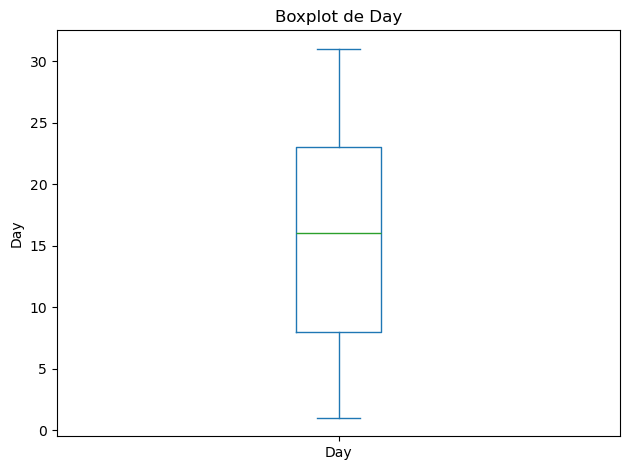

In [101]:
# Se grafica el boxplot para la variable "Day"
df['Day'].plot.box()
plt.title('Boxplot de Day')
plt.ylabel('Day')
plt.tight_layout()
plt.show()

Vemos mucha dispersión (IQR >> 20%), reflejando la naturaleza estocástica de los días en que ocurren los accidentes.

##### Ground: Estadística clásica

In [87]:
# Se calculan las medidas de tendencia central de la variable "Ground"
mean   = df['Ground'].mean()
median = df['Ground'].median()
mode   = df['Ground'].mode()[0]
print(f'Media de Ground: {mean:.2f}')
print(f'Mediana de Ground: {median:.2f}')
print(f'Moda de Ground: {mode:.2f}')

# Se calculan las medidas de dispersión para la variable "Ground"
variance = df['Ground'].var()
std_dev  = df['Ground'].std()
print(f'Varianza de Ground: {variance:.2f}')
print(f'Desvío estándar de Ground: {std_dev:.2f}')

# Se calcula la curtosis y la asimetría para la variable "Ground"
kurtosis = df['Ground'].kurtosis()
skewness = df['Ground'].skew()
print(f'Curtosis de Ground: {kurtosis:.2f}')
print(f'Asimetría de Ground: {skewness:.2f}')


Media de Ground: 1.70
Mediana de Ground: 0.00
Moda de Ground: 0.00
Varianza de Ground: 3036.57
Desvío estándar de Ground: 55.11
Curtosis de Ground: 2458.12
Asimetría de Ground: 49.33


Debido al outlier extremo del atentado del 11 de septiembre de 2001, la varianza es extremadamente alta. La forma es extremadamente asimétrica y leptocúrtica.

No aporta información relevante un histograma en este caso y se omite el gráfico.

##### Ground: Estadística robusta

In [88]:
# Se calculan los cuartiles para la variable "Ground"
q1 = df['Ground'].quantile(0.25)
q2 = df['Ground'].quantile(0.50)
q3 = df['Ground'].quantile(0.75)
print(f'Primer cuartil (Q1) de Ground: {q1:.0f}')
print(f'Segundo cuartil (Q2) de Ground: {q2:.0f}. Es igual a la mediana.')
print(f'Tercer cuartil (Q3) de Ground: {q3:.0f}')

# Se calcula la desviación absoluta mediana (MAD) para la variable "Ground"
mad = (df['Ground'] - df['Ground'].median()).abs().median()
print(f'Desviación absoluta mediana (MAD) de Ground: {mad:.2f}')

# Se calcula el rango intercuartílico (IQR) para la variable "Ground"
iqr = q3 - q1
rango_total = df['Ground'].max() - df['Ground'].min()
print(f'Rango intercuartílico (IQR) de Ground: {iqr:.0f} ({iqr/rango_total*100:.2f}%)')

Primer cuartil (Q1) de Ground: 0
Segundo cuartil (Q2) de Ground: 0. Es igual a la mediana.
Tercer cuartil (Q3) de Ground: 0
Desviación absoluta mediana (MAD) de Ground: 0.00
Rango intercuartílico (IQR) de Ground: 0 (0.00%)


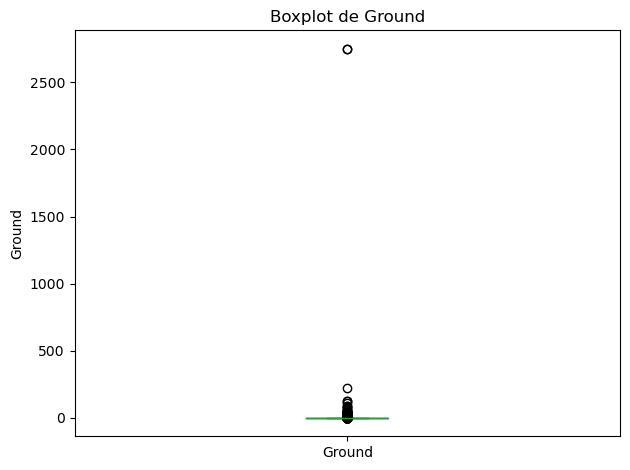

In [92]:
# Se grafica el boxplot para la variable "Ground"
df['Ground'].plot.box()
plt.title('Boxplot de Ground')
plt.ylabel('Ground')
plt.tight_layout()
plt.show()

Ayudándonos de la estadística robusta, vemos que la gran mayoría de los datos son de valor igual a 0 (la caja se aplasta en el valor 0), con algunas outliers en el orden las decenas, y un outlier de 2750.

##### Fatalities: Estadística clásica

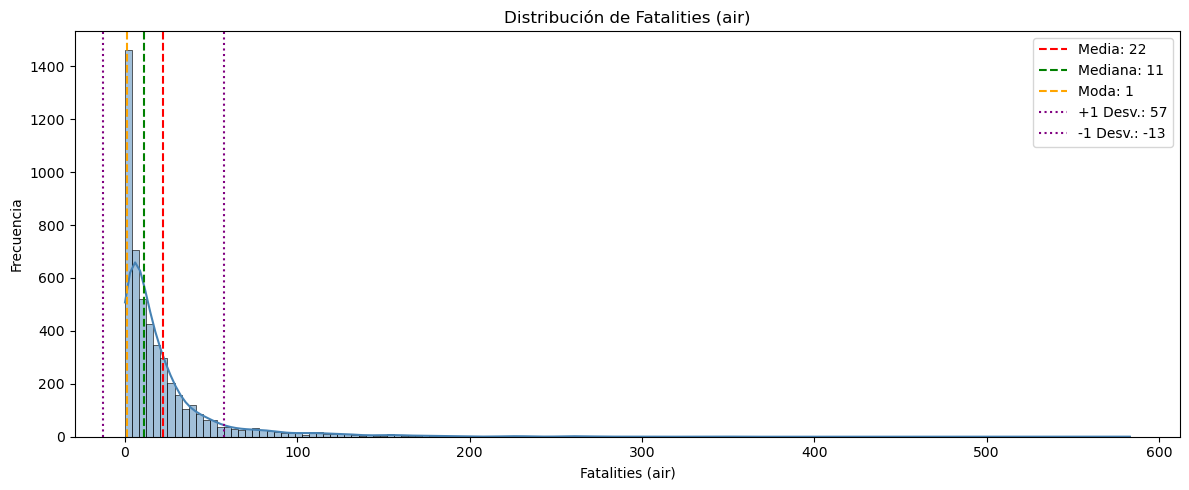

In [95]:
# Se grafica el hisograma con las medidas de tendencia central y dispersión para la variable "Fatalities (air)"
mean   = df['Fatalities (air)'].mean()
median = df['Fatalities (air)'].median()
mode   = df['Fatalities (air)'].mode()[0]
std    = df['Fatalities (air)'].std()

plt.figure(figsize=(12, 5))
sns.histplot(df['Fatalities (air)'], kde=True, color='steelblue')

plt.axvline(mean,       color='red',    linestyle='--', linewidth=1.5, label=f'Media: {mean:.0f}')
plt.axvline(median,     color='green',  linestyle='--', linewidth=1.5, label=f'Mediana: {median:.0f}')
plt.axvline(mode,       color='orange', linestyle='--', linewidth=1.5, label=f'Moda: {mode}')
plt.axvline(mean + std, color='purple', linestyle=':',  linewidth=1.5, label=f'+1 Desv.: {mean+std:.0f}')
plt.axvline(mean - std, color='purple', linestyle=':',  linewidth=1.5, label=f'-1 Desv.: {mean-std:.0f}')

plt.title('Distribución de Fatalities (air)')
plt.xlabel('Fatalities (air)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()


In [96]:
# Se calculan las medidas de dispersión para la variable "Fatalities (air)"
variance = df['Fatalities (air)'].var()
std_dev  = df['Fatalities (air)'].std()
print(f'Varianza de Fatalities (air): {variance:.2f}')
print(f'Desvío estándar de Fatalities (air): {std_dev:.2f}')

Varianza de Fatalities (air): 1221.43
Desvío estándar de Fatalities (air): 34.95


In [97]:
# Se calcula la curtosis y la asimetría para la variable "Fatalities (air)"
kurtosis = df['Fatalities (air)'].kurtosis()
skewness = df['Fatalities (air)'].skew()
print(f'Curtosis de Fatalities (air): {kurtosis:.2f}')
print(f'Asimetría de Fatalities (air): {skewness:.2f}')

Curtosis de Fatalities (air): 36.87
Asimetría de Fatalities (air): 4.62


La forma es bastánte asimétrica (asimetría > 1) y leptocúrtica (curtosis > 1), lo cual se refleja en el histograma, que muestra una distribución con una cola larga hacia la derecha, indicando que hay algunos accidentes con un número muy alto de fatalidades, mientras que la mayoría de los accidentes tienen un número relativamente bajo de fatalidades.

##### Fatalities: Estadística robusta

In [98]:
# Se calculan los cuartiles para la variable "Fatalities (air)"
q1 = df['Fatalities (air)'].quantile(0.25)
q2 = df['Fatalities (air)'].quantile(0.50)
q3 = df['Fatalities (air)'].quantile(0.75)
print(f'Primer cuartil (Q1) de Fatalities (air): {q1:.0f}')
print(f'Segundo cuartil (Q2) de Fatalities (air): {q2:.0f}. Es igual a la mediana.')
print(f'Tercer cuartil (Q3) de Fatalities (air): {q3:.0f}')

# Se calcula la desviación absoluta mediana (MAD) para la variable "Fatalities (air)"
mad = (df['Fatalities (air)'] - df['Fatalities (air)'].median()).abs().median()
print(f'Desviación absoluta mediana (MAD) de Fatalities (air): {mad:.2f}')

# Se calcula el rango intercuartílico (IQR) para la variable "Fatalities (air)"
iqr = q3 - q1
rango_total = df['Fatalities (air)'].max() - df['Fatalities (air)'].min()
print(f'Rango intercuartílico (IQR) de Fatalities (air): {iqr:.0f} ({iqr/rango_total*100:.2f}%)')

Primer cuartil (Q1) de Fatalities (air): 4
Segundo cuartil (Q2) de Fatalities (air): 11. Es igual a la mediana.
Tercer cuartil (Q3) de Fatalities (air): 25
Desviación absoluta mediana (MAD) de Fatalities (air): 9.00
Rango intercuartílico (IQR) de Fatalities (air): 21 (3.60%)


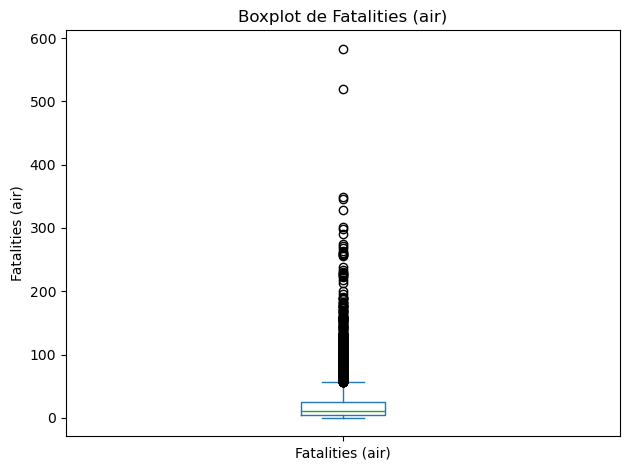

In [103]:
# Se grafica el boxplot para la variable "Fatalities (air)"
df['Fatalities (air)'].plot.box()
plt.title('Boxplot de Fatalities (air)')
plt.ylabel('Fatalities (air)')
plt.tight_layout()
plt.show()

Observamos que la variable tiene bastantes outliers, con el 50% de los datos concentrados entre 4 y 25 fatalidades.

##### Aboard: Estadística clásica

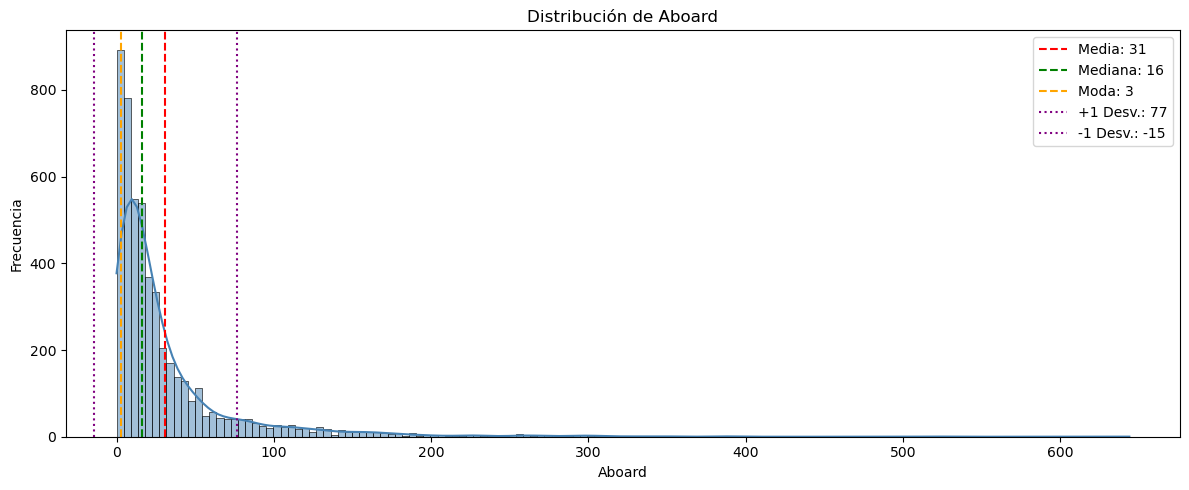

In [104]:
# Se grafica el hisograma con las medidas de tendencia central y dispersión para la variable "Aboard"
mean   = df['Aboard'].mean()
median = df['Aboard'].median()
mode   = df['Aboard'].mode()[0]
std    = df['Aboard'].std()

plt.figure(figsize=(12, 5))
sns.histplot(df['Aboard'], kde=True, color='steelblue')

plt.axvline(mean,       color='red',    linestyle='--', linewidth=1.5, label=f'Media: {mean:.0f}')
plt.axvline(median,     color='green',  linestyle='--', linewidth=1.5, label=f'Mediana: {median:.0f}')
plt.axvline(mode,       color='orange', linestyle='--', linewidth=1.5, label=f'Moda: {mode}')
plt.axvline(mean + std, color='purple', linestyle=':',  linewidth=1.5, label=f'+1 Desv.: {mean+std:.0f}')
plt.axvline(mean - std, color='purple', linestyle=':',  linewidth=1.5, label=f'-1 Desv.: {mean-std:.0f}')

plt.title('Distribución de Aboard')
plt.xlabel('Aboard')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()


In [105]:
# Se calculan las medidas de dispersión para la variable "Aboard"
variance = df['Aboard'].var()
std_dev  = df['Aboard'].std()
print(f'Varianza de Aboard: {variance:.2f}')
print(f'Desvío estándar de Aboard: {std_dev:.2f}')

Varianza de Aboard: 2092.16
Desvío estándar de Aboard: 45.74


In [106]:
# Se calcula la curtosis y la asimetría para la variable "Aboard"
kurtosis = df['Aboard'].kurtosis()
skewness = df['Aboard'].skew()
print(f'Curtosis de Aboard: {kurtosis:.2f}')
print(f'Asimetría de Aboard: {skewness:.2f}')

Curtosis de Aboard: 23.91
Asimetría de Aboard: 3.93


Similar a la variable "Fatalities", la forma es bastante asimétrica y leptocúrtica, sugiriendo que la mayoría de la mayoría de los accidentes tienen un número relativamente bajo de personas a bordo.

##### Aboard: Estadística robusta

In [107]:
# Se calculan los cuartiles para la variable "Aboard"
q1 = df['Aboard'].quantile(0.25)
q2 = df['Aboard'].quantile(0.50)
q3 = df['Aboard'].quantile(0.75)
print(f'Primer cuartil (Q1) de Aboard: {q1:.0f}')
print(f'Segundo cuartil (Q2) de Aboard: {q2:.0f}. Es igual a la mediana.')
print(f'Tercer cuartil (Q3) de Aboard: {q3:.0f}')

# Se calcula la desviación absoluta mediana (MAD) para la variable "Aboard"
mad = (df['Aboard'] - df['Aboard'].median()).abs().median()
print(f'Desviación absoluta mediana (MAD) de Aboard: {mad:.2f}')

# Se calcula el rango intercuartílico (IQR) para la variable "Aboard"
iqr = q3 - q1
rango_total = df['Aboard'].max() - df['Aboard'].min()
print(f'Rango intercuartílico (IQR) de Aboard: {iqr:.0f} ({iqr/rango_total*100:.2f}%)')

Primer cuartil (Q1) de Aboard: 7
Segundo cuartil (Q2) de Aboard: 16. Es igual a la mediana.
Tercer cuartil (Q3) de Aboard: 34
Desviación absoluta mediana (MAD) de Aboard: 11.00
Rango intercuartílico (IQR) de Aboard: 28 (4.27%)


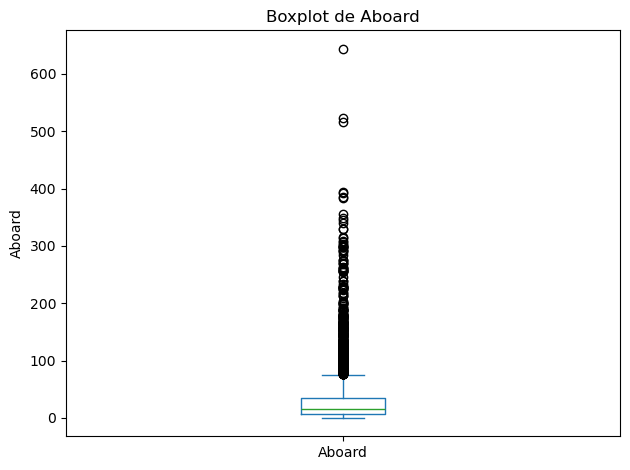

In [108]:
# Se grafica el boxplot para la variable "Aboard"
df['Aboard'].plot.box()
plt.title('Boxplot de Aboard')
plt.ylabel('Aboard')
plt.tight_layout()
plt.show()

Se puede deducir de los gráficos que existe una cierta correlación entre el número de personas a bordo y el número de fatalidades, indicando la baja supervivencia en los accidentes aéreos.

#### Relación entre variables

Las variables *Year* y *Day* son totalmente aleatorias e independientes.

La variable *Ground* es un outlier extremo, siendo generalmente 0, por lo que más que una variable, es una constate. Podemos decir que los accidentes aéreos, en general, no involucran fatalidades en tierra.

Las variables *Fatalities* y *Aboard* muestran una correlación positiva, indicando que a mayor número de personas a bordo, mayor número de fatalidades, lo cual es lógico dado que la supervivencia en los accidentes aéreos suele ser baja.

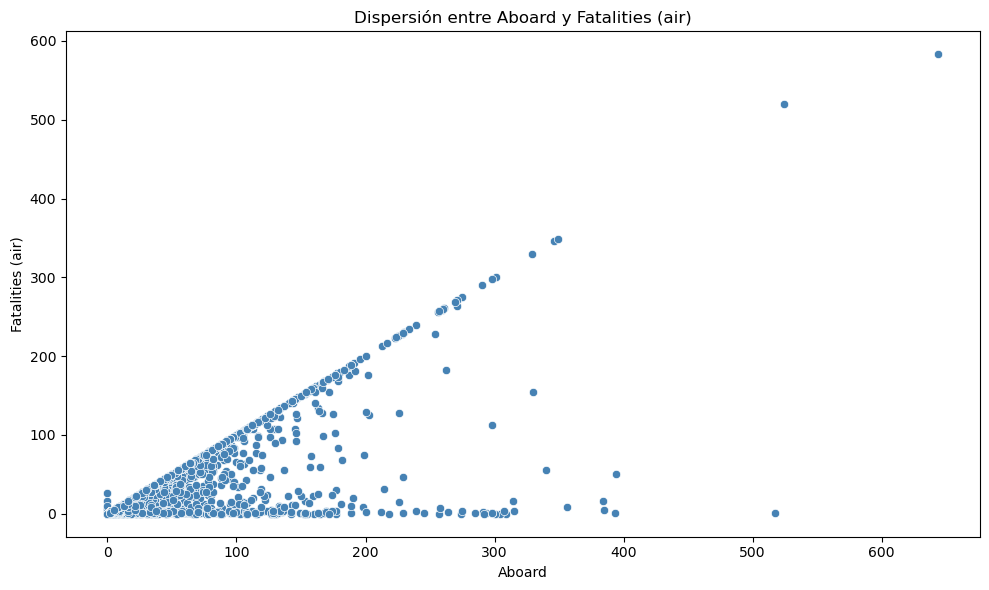

In [115]:
# Gráfico de dispersión entre "Aboard" y "Fatalities (air)"
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Aboard', y='Fatalities (air)', data=df, color='steelblue')
plt.title('Dispersión entre Aboard y Fatalities (air)')
plt.xlabel('Aboard')
plt.ylabel('Fatalities (air)')
plt.tight_layout()
plt.show()

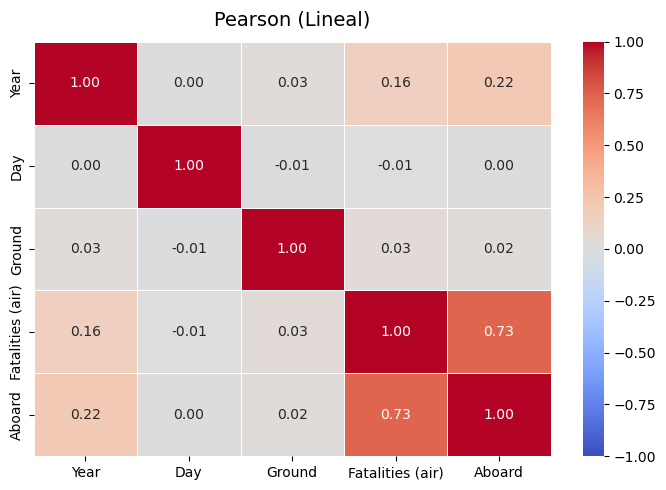

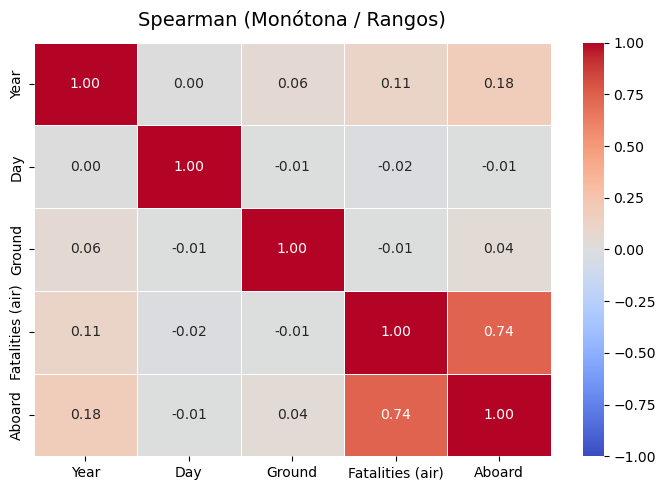

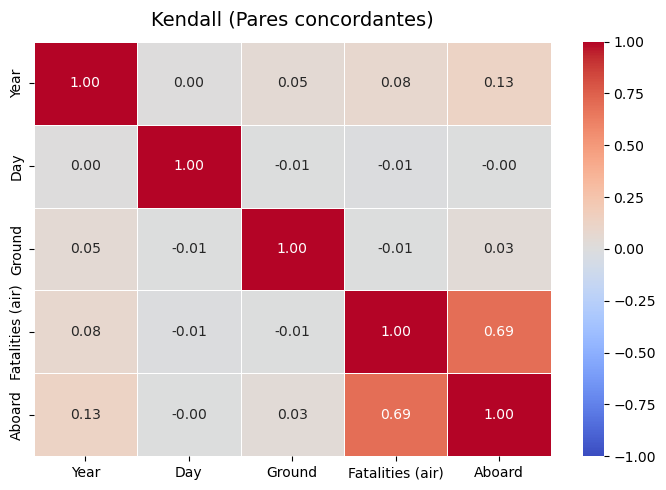

In [ ]:
# Se calculan las matrices de correlación para las variables numéricas y se grafican con heatmaps
corr_pearson  = df[numerical_vars].corr(method='pearson')
corr_spearman = df[numerical_vars].corr(method='spearman')
corr_kendall  = df[numerical_vars].corr(method='kendall')

matrices = [corr_pearson, corr_spearman, corr_kendall]
titulos  = ['Pearson (Lineal)', 'Spearman (Monótona / Rangos)', 'Kendall (Pares concordantes)']

for matriz, titulo in zip(matrices, titulos):
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matriz,
        annot=True,
        cmap='coolwarm',
        vmin=-1, vmax=1,
        fmt=".2f",
        linewidths=0.5,
    )
    plt.title(titulo, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()


#### Variables categóricas

No todas las variables categóricas son relevantes para el análisis, por lo que se seleccionan únicamente aquellas que aportan información útil sobre los accidentes aéreos:
- Quarter
- Month
- Country/Region
- Aircraft Manufacturer
- Aircraft
- Location
- Operator

Medidas de concentración de categorías:
- Moda y proporción de la moda.
- Multimodalidad.

Medidas de distribución y frecuencias:
- Frecuencias absolutas y relativas.
- Rango de frecuencias.

Medidas de variabilidad:
- Cardinalidad.
- Entropía de Shannon.

##### Concentración de categorías

In [122]:
# Se calcula la moda, la proporción de la moda y la multimodalidad para las variables categóricas
for var in categorical_vars:
    print(f'Medidas de concentración para {var}:')
    mode = df[var].mode()[0]
    prop_mode = (df[var] == mode).mean()
    num_modes = df[var].nunique()
    print(f'  Moda: {mode}')
    print(f'  Proporción de la moda: {prop_mode:.2%}')
    print(f'  Número de categorías (posible multimodalidad): {num_modes}')


Medidas de concentración para Quarter:
  Moda: Qtr 4
  Proporción de la moda: 27.17%
  Número de categorías (posible multimodalidad): 4
Medidas de concentración para Month:
  Moda: December
  Proporción de la moda: 9.87%
  Número de categorías (posible multimodalidad): 12
Medidas de concentración para Country/Region:
  Moda: Russia
  Proporción de la moda: 4.95%
  Número de categorías (posible multimodalidad): 527
Medidas de concentración para Aircraft Manufacturer:
  Moda: Douglas
  Proporción de la moda: 19.74%
  Número de categorías (posible multimodalidad): 633
Medidas de concentración para Aircraft:
  Moda: Boeing B 737
  Proporción de la moda: 1.45%
  Número de categorías (posible multimodalidad): 3525
Medidas de concentración para Location:
  Moda: Moscow Russia
  Proporción de la moda: 0.32%
  Número de categorías (posible multimodalidad): 4170
Medidas de concentración para Operator:
  Moda: Aeroflot
  Proporción de la moda: 3.73%
  Número de categorías (posible multimodalidad)

De este primer análisis, podemos ver que *Quarter* y *Month* están uniformemente distribuidos, por lo que tienen un comportamiento estocástico, es decir, no existe un patrón en los meses o trimestres en que ocurren los accidentes aéreos.

Con esto en mente, descartamos estas dos variables para el análisis de distribución y variabilidad, ya que no aportan información relevante.

Otro punto importante es la cantidad enorme de categorías que existen en las demás variables. Esto representa un reto para poder graficar con claridad la distribución de las categorías. Por el porcentaje de la moda y la cantidad de categorías, se puede deducir que no existe una concentración importante en ninguna categoría, sino que los accidentes aéreos ocurren en una gran variedad de países, con diferentes tipos de aeronaves, operadores y ubicaciones.

Las de las que se puede extraer algo de información son *Country/Region*, *Aircraft Manufacturer* y *Operator*. Nos indica que existe una tendencia de accidentes aéreos en Rusia, cuyo mayor operador es Aeroflot, y que los aviones más accidentados son los fabricados por Douglas.

##### Distribución y frecuencias

Se decide aplicar un análisis de frecuencias únicamente a las variables *Country/Region*, *Aircraft Manufacturer* y *Operator*, ya que el resto de las variables tienen una distribución uniforme, o una cantidad tan grande de categorías que no aportan información relevante.

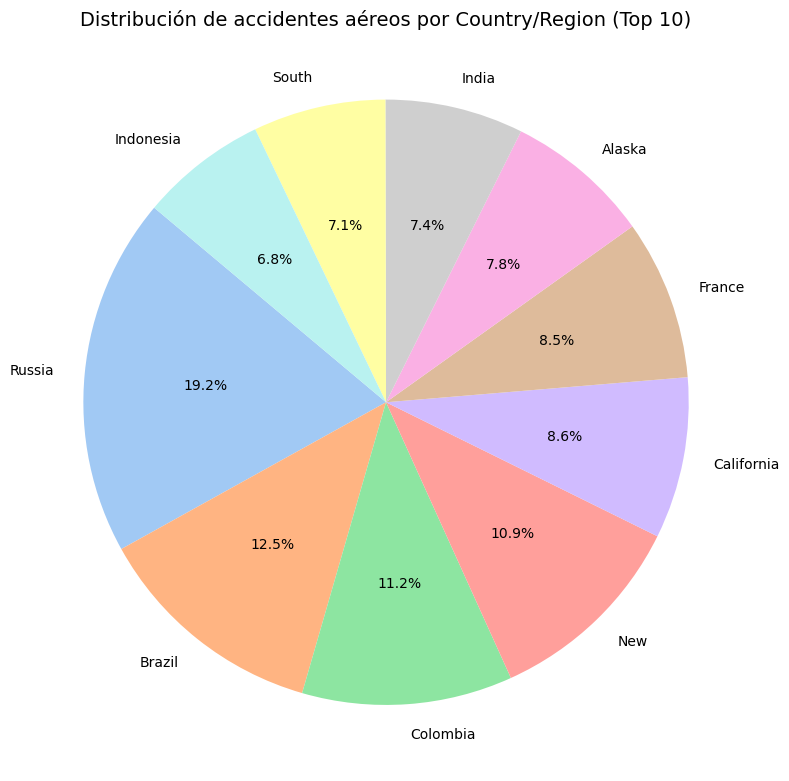

In [127]:
# Gráfico de torta para la variable "Country/Region", teniendo en cuenta las 10 regiones más frecuentes con accidentes aéreos
top_countries = df['Country/Region'].value_counts().nlargest(10)
plt.figure(figsize=(8, 8))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribución de accidentes aéreos por Country/Region (Top 10)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

Vemos que existe un valor *New* que no corresponde a ningún país o región a primera vista.

Haciendo una comparación con la base de datos original (https://www.planecrashinfo.com/), se comprueba que los datos corresponden a accidentes aéreos ocurridos en ciudades o regiones como "New York", "New Jersey", "New Mexico", etc. Esto se debe a que el nombre completo se truncó a "New" al importar los datos, lo cual es un error común al manejar datos con nombres largos o con espacios.

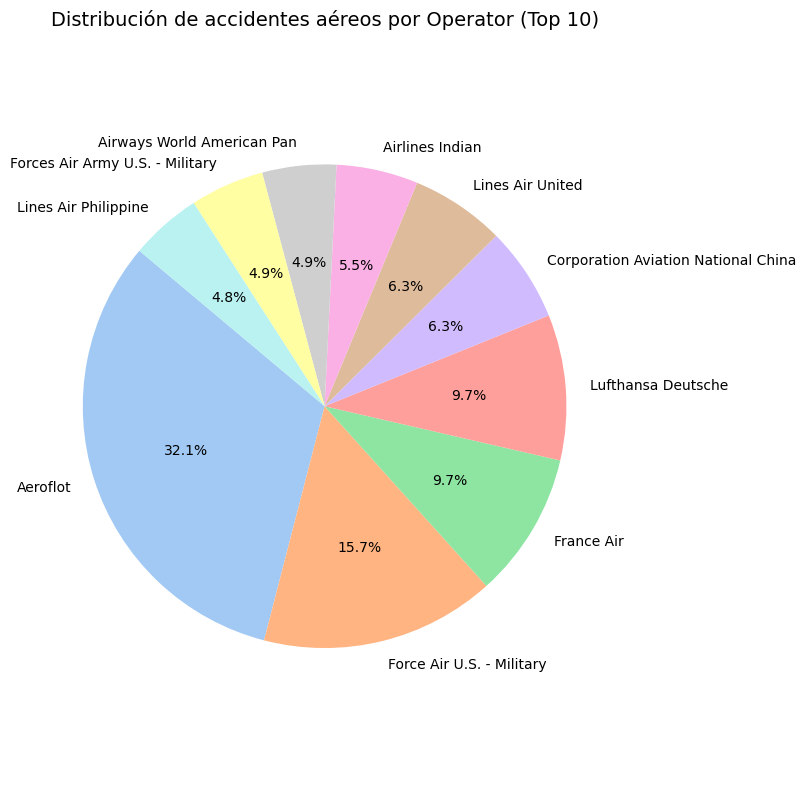

In [129]:
# Gráfico de torta para la variable "Operator", teniendo en cuenta las 10 operadoras más frecuentes con accidentes aéreos
top_operators = df['Operator'].value_counts().nlargest(10)
plt.figure(figsize=(8, 8))
plt.pie(top_operators, labels=top_operators.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribución de accidentes aéreos por Operator (Top 10)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

Se podría deducir que operadores con una gran flota a menudo tienen más accidentes aéreos, lo cual es lógico dado que operan más vuelos. Sin embargo, esto no necesariamente indica que sean menos seguros, sino que simplemente tienen una mayor exposición al riesgo debido a la cantidad de vuelos que realizan.

Sin embargo, "Aeroflot" es un caso interesante, ya que tiene una cantidad de accidentes aéreos desproporcionadamente alta en comparación con otros operadores, lo cual podría indicar problemas de seguridad específicos de esa aerolínea, o podría reflejar la gran cantidad de vuelos que realiza, especialmente en la época soviética donde la seguridad aérea era un problema importante.

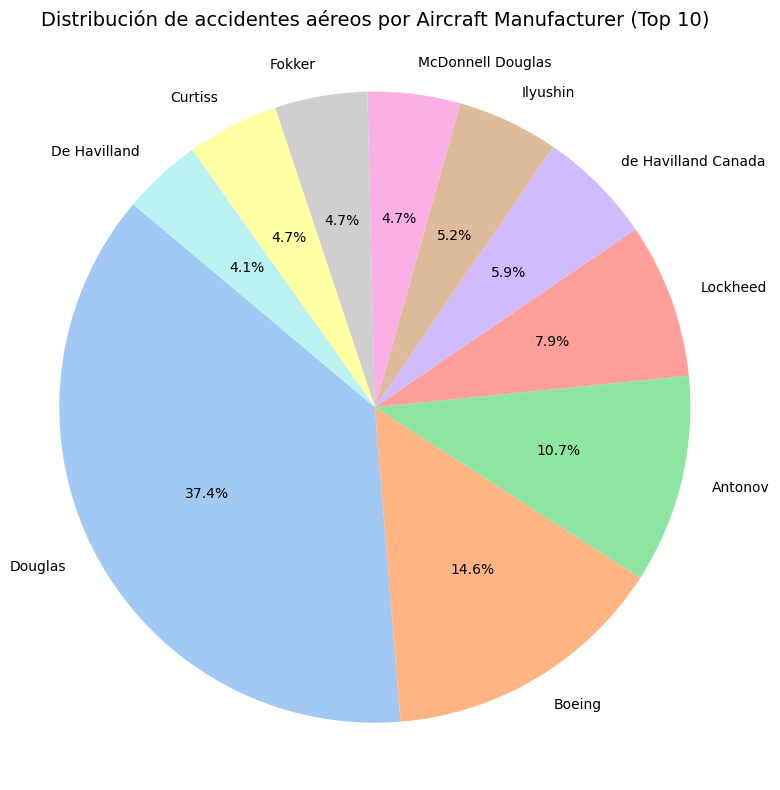

In [130]:
# Gráfico de torta para la variable "Aircraft Manufacturer", teniendo en cuenta las 10 operadoras más frecuentes con accidentes aéreos
top_manufacturers = df['Aircraft Manufacturer'].value_counts().nlargest(10)
plt.figure(figsize=(8, 8))
plt.pie(top_manufacturers, labels=top_manufacturers.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribución de accidentes aéreos por Aircraft Manufacturer (Top 10)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

Resulta interesante que los aviones más accidentados sean los fabricados por Douglas.

Esta empresa fue una de las principales fabricantes de aviones durante gran parte del siglo XX, produciendo modelos muy populares como el DC-3, DC-4, DC-6 y DC-8, que fueron ampliamente utilizados en la aviación comercial y militar.

Esto podría explicar la alta cantidad de accidentes asociados con el fabricante. Esto no necesariamente implica que sus aviones sean menos seguros, sino que simplemente tuvieron una mayor presencia en el mercado durante un período de tiempo significativo.